# Phase 4 — Modèles d'uplift : à qui l'e-mail fait-il vraiment quelque chose ?

Les phases 2 et 3 ont mesuré l'effet **moyen** des e-mails et montré qu'il pourrait être hétérogène. On cherche maintenant l'**effet individuel conditionnel** (*Conditional Average Treatment Effect*, CATE) :

$$\tau(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x]$$

c'est-à-dire l'effet attendu de l'e-mail **pour un client de profil x**. Si on savait estimer $\tau(x)$, on pourrait envoyer l'e-mail seulement à ceux pour qui il rapporte plus qu'il ne coûte, et choisir le bon e-mail pour chacun.

**Ce n'est pas un modèle de réponse.** Un modèle de réponse classique prédit $P(\text{achat} \mid x)$ et cible les clients les plus susceptibles d'acheter. Mais beaucoup d'entre eux auraient acheté **de toute façon** : leur envoyer l'e-mail ne rapporte rien. La littérature marketing distingue quatre types de clients :

| | Achète sans e-mail | N'achète pas sans e-mail |
|---|---|---|
| **Achète avec e-mail** | *Sure things* (acquis) | **Persuadables** ← la seule cible utile |
| **N'achète pas avec e-mail** | *Sleeping dogs* (effet négatif) | *Lost causes* (perdus) |

Un modèle d'uplift cherche les **persuadables**. On ne peut jamais observer à quel type appartient un client (on ne voit qu'un des deux mondes), d'où des méthodes spécifiques.

**Rappel de la phase 3** : les effets individuels sont petits face au bruit (578 acheteurs sur 64 000). Les modèles seront bruités, et l'**évaluation honnête** est aussi importante que le modèle.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

df = pd.read_csv("../data/hillstrom.csv")

# Covariables pré-traitement (history_segment est redondant avec history)
X = pd.get_dummies(df[["recency", "history", "mens", "womens", "newbie", "zip_code", "channel"]],
                   columns=["zip_code", "channel"], dtype=float)
# Traitement codé 0 = aucun, 1 = e-mail Hommes, 2 = e-mail Femmes
W = df["segment"].map({"No E-Mail": 0, "Mens E-Mail": 1, "Womens E-Mail": 2}).to_numpy()
NOMS = {1: "Mens E-Mail", 2: "Womens E-Mail"}
Y = {m: df[m].to_numpy(dtype=float) for m in ["visit", "conversion", "spend"]}

COULEURS = {"Mens E-Mail": "#2a78d6", "Womens E-Mail": "#eb6834", "hasard": "#8a8984"}
COULEURS_MODELES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "font.size": 10})
print(X.shape, list(X.columns))

(64000, 11) ['recency', 'history', 'mens', 'womens', 'newbie', 'zip_code_Rural', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Multichannel', 'channel_Phone', 'channel_Web']


## 1. Protocole d'évaluation : prédictions hors échantillon par validation croisée

**Le problème** : on ne connaît jamais le vrai $\tau(x)$ d'un client, donc on ne peut pas calculer une erreur de prédiction comme en apprentissage supervisé. On évalue un modèle d'uplift par sa capacité à **classer** les clients : si on trie du plus grand uplift prédit au plus petit, les premiers doivent effectivement montrer un écart traité/contrôle plus grand. Cet écart se mesure **en groupe**, grâce à la randomisation : chaque tranche du classement contient des traités et des contrôles comparables.

**Pourquoi la validation croisée (*cross-fitting*)** : un jeu de test classique à 30 % ne contiendrait qu'environ 40 à 80 acheteurs par groupe, beaucoup trop peu (phase 3). On découpe donc les 64 000 clients en 5 plis. Chaque pli est prédit par un modèle entraîné sur les 4 autres. On obtient ainsi une prédiction **hors échantillon** pour chaque client, et on évalue sur la totalité des données sans jamais évaluer un modèle sur ses propres données d'entraînement.

La stratification se fait sur (groupe × conversion), pour que chaque pli ait la même proportion de traités et d'acheteurs.

In [2]:
K = 5
strates = W * 2 + df["conversion"].to_numpy()

def plis(graine=0):
    return list(StratifiedKFold(K, shuffle=True, random_state=graine).split(X, strates))

# Modèles de base : arbres boostés peu profonds et régularisés (signal faible → éviter le sur-apprentissage)
def classifieur(**kw):
    params = dict(n_estimators=200, max_depth=3, learning_rate=0.03, min_child_weight=20,
                  subsample=0.8, colsample_bytree=0.8, reg_lambda=5, n_jobs=-1, verbosity=0)
    return xgb.XGBClassifier(**{**params, **kw})

def regresseur(**kw):
    params = dict(n_estimators=200, max_depth=3, learning_rate=0.03, min_child_weight=50,
                  subsample=0.8, colsample_bytree=0.8, reg_lambda=5, n_jobs=-1, verbosity=0)
    return xgb.XGBRegressor(**{**params, **kw})

## 2. La métrique : la courbe de Qini

On trie les clients par uplift prédit décroissant. Pour les $k$ premiers, on compte les conversions chez les traités $Y_T(k)$ et chez les contrôles $Y_C(k)$, ainsi que les effectifs $N_T(k)$ et $N_C(k)$. La **courbe de Qini** (Radcliffe, 2007) vaut :

$$Q(k) = Y_T(k) - Y_C(k) \cdot \frac{N_T(k)}{N_C(k)}$$

C'est le **nombre de conversions supplémentaires** obtenues en ciblant les $k$ premiers clients, en corrigeant le contrôle à la même taille que le groupe traité.

- À droite ($k = n$, tout le monde ciblé), Q vaut l'effet total, quel que soit le modèle.
- **Un ciblage au hasard** donne la diagonale entre (0, 0) et (n, Q(n)).
- **Un bon modèle** monte plus vite que la diagonale : les premiers clients ciblés concentrent l'effet.

**Qini normalisé** (le score qu'on utilisera) : l'écart moyen entre la courbe et la diagonale, exprimé en fraction de l'effet total, soit la moyenne sur k de $(Q(k) - \text{diagonale}(k)) / Q(n)$. Il vaut 0 pour un modèle qui ne fait pas mieux que le hasard, et il est positif si le modèle trie bien. Par exemple, 0,2 signifie qu'en moyenne le long du classement, on a déjà récolté 20 % de l'effet total de plus qu'un ciblage au hasard. Un modèle parfait atteint une valeur qui dépend des données (il n'y a pas de maximum universel), d'où l'intérêt de comparer à une **distribution nulle**.

On évalue chaque e-mail **séparément** contre le contrôle (Hommes vs aucun, Femmes vs aucun).

In [3]:
def courbe_qini(uplift, y, t):
    # t = 1 si traité, 0 si contrôle. Retourne Q(k) pour k = 1..n, clients triés par uplift décroissant.
    ordre = np.argsort(-uplift, kind="stable")
    y, t = y[ordre], t[ordre]
    n_t, n_c = np.cumsum(t), np.cumsum(1 - t)
    y_t, y_c = np.cumsum(y * t), np.cumsum(y * (1 - t))
    return y_t - y_c * np.divide(n_t, n_c, out=np.zeros(len(y)), where=n_c > 0)

def qini_normalise(uplift, y, t):
    q = courbe_qini(uplift, y, t)
    diagonale = q[-1] * np.arange(1, len(q) + 1) / len(q)
    return (q - diagonale).mean() / q[-1]

def evaluer(uplift, metrique, traitement):
    # Qini normalisé d'un vecteur d'uplift (pour tous les clients) sur la paire traitement vs contrôle
    masque = (W == traitement) | (W == 0)
    return qini_normalise(uplift[masque], Y[metrique][masque], (W[masque] == traitement).astype(float))

### La distribution nulle : que donne un classement au hasard ?

Avec un signal aussi faible, un modèle peut avoir un Qini positif **par chance**. On calcule le Qini de 500 classements aléatoires : leur dispersion donne l'échelle du bruit. Un modèle n'est crédible que s'il sort nettement de cette distribution (on calcule une p-value empirique).

In [4]:
rng = np.random.default_rng(0)
N_PERMUTATIONS = 500
nulles = {(m, g): np.array([evaluer(rng.random(len(df)), m, g) for _ in range(N_PERMUTATIONS)])
          for m in ["conversion", "spend", "visit"] for g in (1, 2)}

pd.DataFrame({f"{m} / {NOMS[g]}": {"moyenne": v.mean(), "écart-type": v.std(), "quantile 95 %": np.quantile(v, 0.95)}
              for (m, g), v in nulles.items()}).T.round(3)

,moyenne,écart-type,quantile 95 %
conversion / Mens E-Mail,0.001,0.039,0.068
conversion / Womens E-Mail,-0.003,0.080,0.136
spend / Mens E-Mail,-0.002,0.056,0.081
spend / Womens E-Mail,-0.000,0.086,0.134
visit / Mens E-Mail,0.001,0.013,0.022
visit / Womens E-Mail,-0.000,0.022,0.036


In [5]:
def p_value_empirique(score, m, g):
    return (1 + (nulles[(m, g)] >= score).sum()) / (1 + N_PERMUTATIONS)

def tableau_scores(uplifts):
    # uplifts : {nom du modèle : matrice n × 3 (colonnes 1 et 2 = uplift prédit des deux e-mails)}
    lignes = []
    for nom, U in uplifts.items():
        for g in (1, 2):
            ligne = {"modèle": nom, "e-mail": NOMS[g]}
            for m in ["conversion", "spend", "visit"]:
                s = evaluer(U[:, g], m, g)
                ligne[f"Qini {m}"] = round(s, 3)
                ligne[f"p {m}"] = round(p_value_empirique(s, m, g), 3)
            lignes.append(ligne)
    return pd.DataFrame(lignes).set_index(["e-mail", "modèle"]).sort_index()

## 3. Point de départ : le modèle de réponse (la mauvaise méthode)

Approche « classique » : prédire $P(\text{conversion} \mid x, \text{e-mail reçu})$ à partir des seuls clients traités, et cibler les plus probables acheteurs. On l'évalue avec la même courbe de Qini, en utilisant ce score de réponse comme classement.

In [6]:
def t_learner(y, fabrique, proba=True, graine=0):
    # Un modèle par groupe (0, 1, 2) ; retourne la matrice n × 3 des prédictions hors échantillon
    P = np.zeros((len(df), 3))
    for train, test in plis(graine):
        for a in range(3):
            lignes_a = train[W[train] == a]
            modele = fabrique().fit(X.iloc[lignes_a], y[lignes_a])
            P[test, a] = modele.predict_proba(X.iloc[test])[:, 1] if proba else modele.predict(X.iloc[test])
    return P

P_conv = t_learner(Y["conversion"], classifieur)
reponse = P_conv.copy()   # score de réponse = probabilité d'acheter si traité (colonnes 1 et 2)
tableau_scores({"modèle de réponse": reponse})

,,Qini conversion,p conversion,Qini spend,p spend,Qini visit,p visit
e-mail,modèle,,,,,,
Mens E-Mail,modèle de réponse,0.024,0.297,0.038,0.261,0.022,0.050
Womens E-Mail,modèle de réponse,0.135,0.056,0.123,0.076,0.093,0.002


**Lecture** : pour l'e-mail Femmes, le modèle de réponse trie déjà un peu mieux que le hasard. Il n'est pas absurde : les clients les plus actifs ont aussi un peu plus d'uplift en valeur absolue. Mais pour l'e-mail Hommes, il ne fait **pas mieux que le hasard**. Cibler « ceux qui achètent » n'est pas cibler « ceux que l'e-mail fait acheter ». Voyons si les vrais modèles d'uplift font mieux.

## 4. Les méta-apprenants (*meta-learners*)

Ils transforment le problème causal en un ou plusieurs problèmes d'apprentissage supervisé classiques, résolus avec n'importe quel modèle (ici XGBoost) :

**S-learner** (*Single*) : un seul modèle $\mu(x, w)$ avec le traitement comme variable explicative, puis $\hat\tau(x) = \hat\mu(x, 1) - \hat\mu(x, 0)$. Simple, mais un modèle à arbres peut **ignorer** la variable de traitement si son effet est faible devant les autres variables, et l'uplift prédit est alors écrasé vers 0.

**T-learner** (*Two*) : un modèle par groupe, $\hat\mu_1$ sur les traités et $\hat\mu_0$ sur les contrôles, puis $\hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$. Chaque modèle peut se concentrer sur son groupe. Mais la différence de deux prédictions bruitées est **très bruitée**, et chacun peut sur-apprendre des motifs différents.

**Transformation de la cible** (*transformed outcome*, Athey & Imbens 2015) : avec une probabilité de traitement connue $e$ (ici 1/2 au sein de chaque paire), on construit

$$Z = Y \cdot \left(\frac{T}{e} - \frac{1 - T}{1 - e}\right)$$

Grâce à la randomisation, $\mathbb{E}[Z \mid x] = \tau(x)$ **exactement**. On régresse donc directement Z sur x, avec un seul modèle qui vise l'uplift. Le prix à payer : Z est extrêmement bruité (il vaut 0, +2 ou −2).

**X-learner** (Künzel et al., 2019) : on part du T-learner, puis on impute un effet individuel à chaque client (traité : $Y - \hat\mu_0(x)$ ; contrôle : $\hat\mu_1(x) - Y$), et on régresse ces effets imputés sur x. Conçu pour les cas où l'effet est plus simple que les niveaux de base.

In [7]:
def s_learner(y, fabrique, proba=True, graine=0):
    P = np.zeros((len(df), 3))
    for train, test in plis(graine):
        X_train = X.iloc[train].assign(w_hommes=(W[train] == 1) * 1.0, w_femmes=(W[train] == 2) * 1.0)
        modele = fabrique().fit(X_train, y[train])
        for a in range(3):
            X_test = X.iloc[test].assign(w_hommes=float(a == 1), w_femmes=float(a == 2))
            P[test, a] = modele.predict_proba(X_test)[:, 1] if proba else modele.predict(X_test)
    return P

def transformation_cible(y, graine=0):
    U = np.zeros((len(df), 3))
    for train, test in plis(graine):
        for a in (1, 2):
            paire = train[(W[train] == a) | (W[train] == 0)]
            t = (W[paire] == a).astype(float)
            e = t.mean()
            z = y[paire] * (t / e - (1 - t) / (1 - e))
            U[test, a] = regresseur().fit(X.iloc[paire], z).predict(X.iloc[test])
    return U

def x_learner(y, graine=0):
    U = np.zeros((len(df), 3))
    for train, test in plis(graine):
        mu = {a: classifieur().fit(X.iloc[train[W[train] == a]], y[train[W[train] == a]]) for a in range(3)}
        for a in (1, 2):
            traites, controles = train[W[train] == a], train[W[train] == 0]
            effet_traites = y[traites] - mu[0].predict_proba(X.iloc[traites])[:, 1]
            effet_controles = mu[a].predict_proba(X.iloc[controles])[:, 1] - y[controles]
            tau_1 = regresseur().fit(X.iloc[traites], effet_traites)
            tau_0 = regresseur().fit(X.iloc[controles], effet_controles)
            # Pondération par la probabilité de traitement : ici ≈ 1/2, donc moyenne simple
            U[test, a] = 0.5 * tau_1.predict(X.iloc[test]) + 0.5 * tau_0.predict(X.iloc[test])
    return U

logistique = lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=2000))

P_s = s_learner(Y["conversion"], classifieur)
P_t_log = t_learner(Y["conversion"], logistique)
uplifts = {
    "modèle de réponse": reponse,
    "S-learner (XGBoost)": P_s - P_s[:, [0]],
    "T-learner (XGBoost)": P_conv - P_conv[:, [0]],
    "T-learner (logistique)": P_t_log - P_t_log[:, [0]],
    "transformation de cible": transformation_cible(Y["conversion"]),
    "X-learner": x_learner(Y["conversion"]),
}
scores = tableau_scores(uplifts)
scores

Qini conversion  p conversion  \
e-mail        modèle                                                   
Mens E-Mail   S-learner (XGBoost)                0.006         0.459   
              T-learner (XGBoost)               -0.014         0.657   
              T-learner (logistique)            -0.038         0.838   
              X-learner                         -0.030         0.774   
              modèle de réponse                  0.024         0.297   
              transformation de cible           -0.035         0.822   
Womens E-Mail S-learner (XGBoost)                0.256         0.002   
              T-learner (XGBoost)                0.295         0.002   
              T-learner (logistique)             0.216         0.008   
              X-learner                          0.156         0.026   
              modèle de réponse                  0.135         0.056   
              transformation de cible            0.165         0.022   

                                       Qini spend  p spend  Qini visit  \
e-mail        modèle                                                     
Mens E-Mail   S-learner (XGBoost)           0.019    0.377       0.020   
              T-learner (XGBoost)           0.008    0.443       0.007   
              T-learner (logistique)       -0.015    0.623       0.027   
              X-learner                     0.005    0.463       0.012   
              modèle de réponse             0.038    0.261       0.022   
              transformation de cible      -0.026    0.689       0.026   
Womens E-Mail S-learner (XGBoost)           0.203    0.004       0.147   
              T-learner (XGBoost)           0.249    0.002       0.129   
              T-learner (logistique)        0.178    0.008       0.149   
              X-learner                     0.116    0.086       0.113   
              modèle de réponse             0.123    0.076       0.093   
              transformation de cible       0.097    0.132       0.100   

                                       p visit  
e-mail        modèle                            
Mens E-Mail   S-learner (XGBoost)        0.068  
              T-learner (XGBoost)        0.321  
              T-learner (logistique)     0.022  
              X-learner                  0.180  
              modèle de réponse          0.050  
              transformation de cible    0.028  
Womens E-Mail S-learner (XGBoost)        0.002  
              T-learner (XGBoost)        0.002  
              T-learner (logistique)     0.002  
              X-learner                  0.002  
              modèle de réponse          0.002  
              transformation de cible    0.002

### Lecture : deux histoires très différentes selon l'e-mail

**E-mail Femmes** : tous les méta-apprenants trient **mieux que le hasard** sur la conversion. Les meilleurs, le T-learner et le S-learner XGBoost, ont un Qini ≈ 0,26-0,30 avec p = 0,002, la plus petite p-value possible avec 500 permutations. Leur classement appris sur la conversion se transfère à la dépense. L'effet de l'e-mail Femmes est **réellement hétérogène**, et les modèles le captent. Le S-learner, qui risquait d'ignorer la variable de traitement, s'en sort bien ici : l'effet de l'e-mail Femmes est assez marqué pour que les arbres s'en servent. Le X-learner et la transformation de cible, plus flexibles, sont moins bons : avec si peu d'acheteurs, leur variance l'emporte.

**E-mail Hommes** : **aucun** modèle ne fait mieux que le hasard sur la conversion ni sur la dépense. Ce n'est pas un échec des modèles : avec quatre méthodes différentes qui échouent toutes, la conclusion la plus probable est que **l'effet de l'e-mail Hommes est à peu près homogène**. Il fait acheter à peu près autant chaque type de client, du moins dans la limite de ce que 64 000 clients permettent de distinguer (phase 3).

Ce contraste est une information métier en soi : **l'e-mail Hommes est un « bon e-mail généraliste », l'e-mail Femmes est un e-mail de niche**.

## 5. Courbes de Qini

On visualise les meilleurs modèles face au hasard, pour les deux e-mails. L'axe horizontal est la part de clients ciblés, l'axe vertical les conversions supplémentaires obtenues (pour 1 000 clients de la paire).

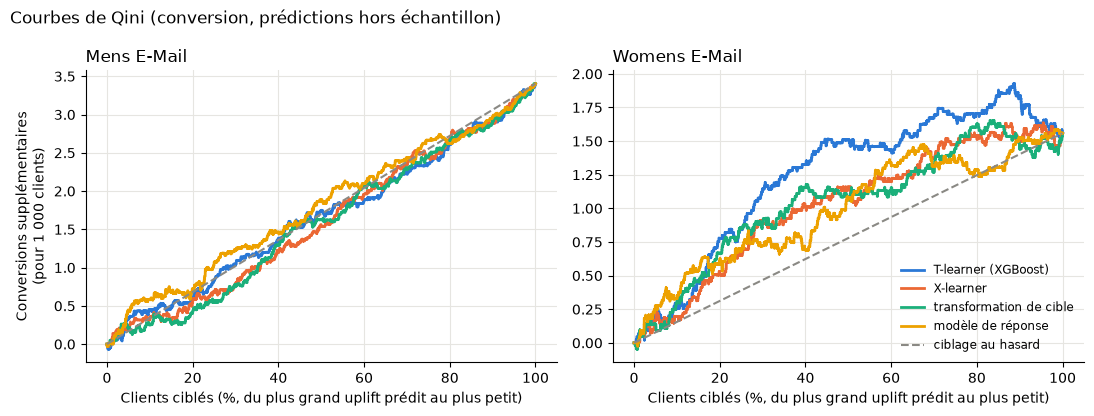

In [8]:
modeles_affiches = ["T-learner (XGBoost)", "X-learner", "transformation de cible", "modèle de réponse"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
for ax, g in zip(axes, (1, 2)):
    masque = (W == g) | (W == 0)
    y, t = Y["conversion"][masque], (W[masque] == g).astype(float)
    n = masque.sum()
    x = np.arange(1, n + 1) / n * 100
    for couleur, nom in zip(COULEURS_MODELES, modeles_affiches):
        q = courbe_qini(uplifts[nom][masque, g], y, t)
        ax.plot(x, q / n * 1000, color=couleur, linewidth=2, label=nom)
    ax.plot([0, 100], [0, q[-1] / n * 1000], color=COULEURS["hasard"], linewidth=1.5, linestyle="--", label="ciblage au hasard")
    ax.set_title(NOMS[g], loc="left")
    ax.set_xlabel("Clients ciblés (%, du plus grand uplift prédit au plus petit)")
axes[0].set_ylabel("Conversions supplémentaires\n(pour 1 000 clients)")
axes[1].legend(frameon=False, fontsize=8.5, loc="lower right")
fig.suptitle("Courbes de Qini (conversion, prédictions hors échantillon)", x=0.01, ha="left")
plt.tight_layout()
plt.savefig("../docs/figures/04_courbes_qini.png", dpi=150)
plt.show()

**Lecture** :
- **E-mail Femmes** : les courbes passent nettement au-dessus de la diagonale. Avec le T-learner, cibler les **45 %** de clients au plus fort uplift prédit apporte déjà ≈ 1,5 conversion supplémentaire pour 1 000, **soit la quasi-totalité de l'effet total** (≈ 1,55). Les 55 % restants n'apportent presque rien. La courbe dépasse même le total vers 80-90 % : les derniers clients du classement auraient un effet légèrement négatif (dans la limite du bruit).
- **E-mail Hommes** : les courbes restent collées à la diagonale, en serpentant autour d'elle. Tous les clients contribuent à peu près également.

## 6. Vérification par déciles : l'uplift prédit se retrouve-t-il dans les données ?

Une autre façon de juger un modèle : découper les clients en 10 déciles d'uplift prédit, et mesurer dans chaque décile l'**uplift observé** (taux de conversion des traités − taux des contrôles). Si le modèle est bon, l'uplift observé décroît du décile 1 au décile 10. On montre le T-learner XGBoost, avec des intervalles de confiance à 95 % (z-test de la phase 2) pour visualiser le bruit.

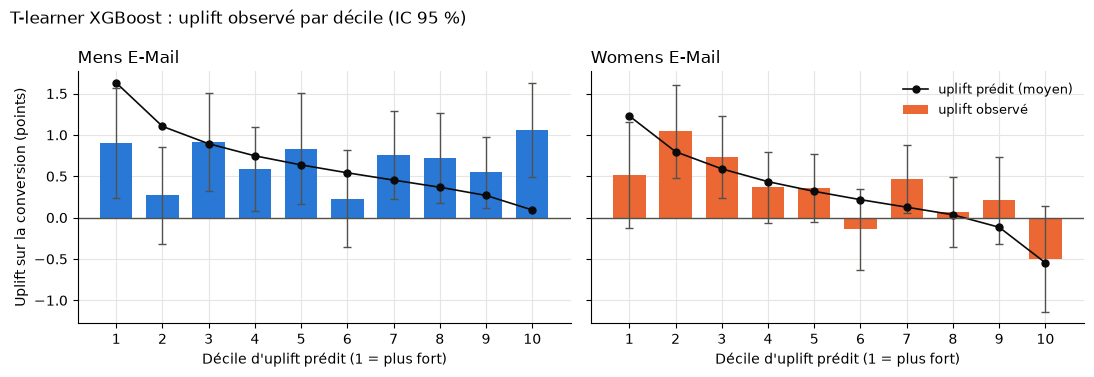

In [9]:
def uplift_par_decile(uplift, metrique, g, n_deciles=10):
    masque = (W == g) | (W == 0)
    u, y, t = uplift[masque], Y[metrique][masque], W[masque] == g
    deciles = pd.qcut(-u, n_deciles, labels=False, duplicates="drop") + 1
    lignes = []
    for d in range(1, n_deciles + 1):
        yt, yc = y[(deciles == d) & t], y[(deciles == d) & ~t]
        se = np.sqrt(yt.var(ddof=1) / len(yt) + yc.var(ddof=1) / len(yc))
        lignes.append({"décile": d, "uplift prédit": u[deciles == d].mean(), "uplift observé": yt.mean() - yc.mean(),
                       "IC95": 1.96 * se, "n": (deciles == d).sum()})
    return pd.DataFrame(lignes)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, g in zip(axes, (1, 2)):
    tab = uplift_par_decile(uplifts["T-learner (XGBoost)"][:, g], "conversion", g)
    ax.bar(tab["décile"], tab["uplift observé"] * 100, color=COULEURS[NOMS[g]], width=0.7, label="uplift observé")
    ax.errorbar(tab["décile"], tab["uplift observé"] * 100, yerr=tab["IC95"] * 100, fmt="none",
                ecolor="#52514e", capsize=3, linewidth=1)
    ax.plot(tab["décile"], tab["uplift prédit"] * 100, "o-", color="#0b0b0b", markersize=5, linewidth=1.2, label="uplift prédit (moyen)")
    ax.axhline(0, color="#52514e", linewidth=1)
    ax.set_xticks(range(1, 11))
    ax.set_xlabel("Décile d'uplift prédit (1 = plus fort)")
    ax.set_title(NOMS[g], loc="left")
axes[0].set_ylabel("Uplift sur la conversion (points)")
axes[1].legend(frameon=False, fontsize=9)
fig.suptitle("T-learner XGBoost : uplift observé par décile (IC 95 %)", x=0.01, ha="left")
plt.tight_layout()
plt.savefig("../docs/figures/04_uplift_deciles.png", dpi=150)
plt.show()

**Lecture** :
- **E-mail Femmes** : l'uplift observé suit l'uplift prédit, avec une tendance décroissante nette malgré des intervalles larges (≈ 4 300 clients par décile, une quarantaine d'acheteurs). Il est élevé dans les déciles 1 à 3 et nul, voire négatif, dans les derniers.
- **E-mail Hommes** : c'est l'image la plus instructive. Le modèle **prédit** un uplift très variable, de 1,6 point (décile 1) à 0,1 point (décile 10), mais l'uplift **observé** est plat, ≈ 0,5-1 point partout, et le décile 10 est même l'un des plus élevés. **Le modèle a inventé de l'hétérogénéité à partir du bruit** : la différence de deux modèles qui sur-apprennent chacun un peu donne des uplifts prédits dispersés, sans réalité. C'est exactement pour cela qu'on ne juge jamais un modèle d'uplift à la dispersion de ses prédictions, mais à leur **validation sur données hors échantillon**.

Les intervalles rappellent la phase 3 : à l'échelle d'un décile, on est loin de pouvoir estimer précisément l'effet. Seule la **tendance d'ensemble** est interprétable.

## 7. Robustesse : stabilité selon le découpage et sensibilité à la régularisation

Deux vérifications :
1. **Graines de validation croisée** : un autre découpage en plis donne-t-il les mêmes conclusions ? On refait le T-learner et le X-learner avec 3 graines.
2. **Régularisation** : un modèle trop contraint (moins d'arbres, profondeur 2, feuilles d'au moins 100 clients) perd-il le signal ?

In [10]:
lignes = []
for graine in [0, 1, 2]:
    P = t_learner(Y["conversion"], classifieur, graine=graine)
    U_x = x_learner(Y["conversion"], graine=graine)
    for nom, U in [("T-learner (XGBoost)", P - P[:, [0]]), ("X-learner", U_x)]:
        for g in (1, 2):
            lignes.append({"graine": graine, "modèle": nom, "e-mail": NOMS[g],
                           "Qini conversion": evaluer(U[:, g], "conversion", g),
                           "Qini spend": evaluer(U[:, g], "spend", g)})
stabilite = pd.DataFrame(lignes)
stabilite.groupby(["e-mail", "modèle"])[["Qini conversion", "Qini spend"]].agg(["mean", "min", "max"]).round(3)

Qini conversion               Qini spend  \
                                             mean    min    max       mean   
e-mail        modèle                                                         
Mens E-Mail   T-learner (XGBoost)           0.008 -0.014  0.031      0.005   
              X-learner                    -0.005 -0.030  0.020     -0.002   
Womens E-Mail T-learner (XGBoost)           0.307  0.295  0.316      0.254   
              X-learner                     0.181  0.156  0.214      0.118   

                                                 
                                     min    max  
e-mail        modèle                             
Mens E-Mail   T-learner (XGBoost) -0.008  0.015  
              X-learner           -0.019  0.009  
Womens E-Mail T-learner (XGBoost)  0.248  0.265  
              X-learner            0.114  0.124

In [11]:
tres_regularise = lambda: classifieur(n_estimators=100, max_depth=2, min_child_weight=100)
P_reg = t_learner(Y["conversion"], tres_regularise)
U_reg = P_reg - P_reg[:, [0]]
print("Écart-type de l'uplift prédit (e-mail Femmes)")
print(f"  T-learner standard        : {uplifts['T-learner (XGBoost)'][:, 2].std() * 100:.3f} point")
print(f"  T-learner très régularisé : {U_reg[:, 2].std() * 100:.3f} point")
tableau_scores({"T-learner très régularisé": U_reg})

Écart-type de l'uplift prédit (e-mail Femmes)
  T-learner standard        : 0.487 point
  T-learner très régularisé : 0.010 point


,,Qini conversion,p conversion,Qini spend,p spend,Qini visit,p visit
e-mail,modèle,,,,,,
Mens E-Mail,T-learner très régularisé,-0.016,0.683,-0.080,0.900,-0.001,0.549
Womens E-Mail,T-learner très régularisé,-0.005,0.489,0.023,0.427,-0.033,0.928


**Lecture** :
- Les conclusions sont **stables** d'une graine à l'autre. L'e-mail Femmes est toujours nettement au-dessus du hasard, l'e-mail Hommes toujours autour de zéro. Les valeurs exactes bougent toutefois de quelques centièmes, ce qui rappelle le niveau de bruit.
- Le modèle très régularisé **perd le signal** : ses prédictions sont presque constantes, et un uplift constant ne trie rien. Avec un signal aussi faible, il faut un équilibre. Trop de régularisation et le modèle ne voit rien, trop peu et il apprend du bruit (le X-learner et la transformation de cible, plus flexibles, en souffrent un peu).

## 8. Qui sont les clients réceptifs à l'e-mail Femmes ?

Un modèle d'uplift XGBoost est une boîte noire. Pour **expliquer** ce qu'il a appris, on ajuste un **arbre de décision peu profond** (profondeur 2) sur ses prédictions hors échantillon : c'est un modèle **substitut** (*surrogate*), qui résume les grandes règles en quelques segments lisibles. On vérifie ensuite, segment par segment, l'**uplift observé** dans les données brutes (différence traités − contrôles), indépendamment du modèle.

In [12]:
from sklearn.tree import DecisionTreeRegressor, export_text

uplift_femmes = uplifts["T-learner (XGBoost)"][:, 2]
# Uplift exprimé en points de pourcentage pour que l'arbre affiche des valeurs lisibles
arbre = DecisionTreeRegressor(max_depth=2, min_samples_leaf=3000, random_state=0).fit(X, uplift_femmes * 100)
print(f"Part de la variance de l'uplift prédit expliquée par l'arbre : R² = {arbre.score(X, uplift_femmes * 100):.2f}\n")
print(export_text(arbre, feature_names=list(X.columns), decimals=2))

Part de la variance de l'uplift prédit expliquée par l'arbre : R² = 0.46

|--- history <= 499.92
|   |--- mens <= 0.50
|   |   |--- value: [0.44]
|   |--- mens >  0.50
|   |   |--- value: [0.02]
|--- history >  499.92
|   |--- recency <= 2.50
|   |   |--- value: [1.20]
|   |--- recency >  2.50
|   |   |--- value: [0.78]



In [13]:
from scipy import stats

feuille = arbre.apply(X)
lignes = []
for f in np.unique(feuille):
    segment = feuille == f
    ligne = {"feuille": f, "clients": segment.sum(), "uplift prédit (pts)": uplift_femmes[segment].mean() * 100}
    for g in (1, 2):
        for m in ["conversion", "spend"]:
            yt, yc = Y[m][segment & (W == g)], Y[m][segment & (W == 0)]
            ligne[f"{NOMS[g]} {m}"] = (yt.mean() - yc.mean()) * (100 if m == "conversion" else 1)
            if g == 2 and m == "spend":
                ligne["p (Femmes, spend)"] = stats.ttest_ind(yt, yc, equal_var=False).pvalue
    lignes.append(ligne)
segments = pd.DataFrame(lignes).set_index("feuille").sort_values("uplift prédit (pts)", ascending=False)
segments.round(3)

,clients,uplift prédit (pts),Mens E-Mail conversion,Mens E-Mail spend,Womens E-Mail conversion,Womens E-Mail spend,"p (Femmes, spend)"
feuille,,,,,,,
5,3740,1.201,1.154,0.966,1.286,1.274,0.103
6,4340,0.783,1.117,1.510,0.734,1.381,0.027
2,26083,0.440,0.481,0.484,0.461,0.599,0.001
3,29837,0.015,0.729,0.885,-0.008,0.023,0.902


**Lecture** : avec seulement 4 segments, l'arbre substitut explique près de la moitié (R² ≈ 0,46) de la variation de l'uplift prédit. Deux variables structurent l'effet de l'e-mail Femmes :
1. **Les gros clients** (`history` > 500 $ sur l'année passée, ≈ 13 % des clients) : l'uplift est le plus fort (≈ +1,2 point de conversion chez les plus récents, `recency` ≤ 2 mois).
2. Pour les autres, **avoir acheté des produits pour hommes** (`mens` = 1) **annule** l'effet de l'e-mail Femmes : uplift observé ≈ 0 sur ≈ 30 000 clients, soit près de la moitié de la base. Sans achat hommes, il est d'environ +0,46 point.

**Les données brutes confirment le modèle** : l'uplift *observé* (traités − contrôles, sans aucun modèle) suit le même ordre que l'uplift prédit, segment par segment. C'est une validation importante, même si elle n'est pas parfaitement indépendante (l'arbre a été construit sur les prédictions des mêmes clients).

À l'inverse, l'**e-mail Hommes** a un effet positif dans tous les segments (de +0,5 à +1,2 point de conversion), sans ordre lié à celui de l'e-mail Femmes : c'est cohérent avec un effet homogène, les écarts entre segments restant dans le bruit.

## 9. Modèle retenu pour la phase 5

Pour décider **qui reçoit quel e-mail**, la phase 5 a besoin, pour chaque client, de l'uplift **en dollars** de chaque e-mail. Deux options :
- **(a)** un T-learner XGBoost directement sur `spend` : cible très bruitée (phase 3) ;
- **(b)** l'uplift de **conversion** × panier moyen : justifié par la phase 2, où le panier moyen ne dépend pas de l'e-mail. On prend le panier moyen des acheteurs ≈ 117 $.

On compare les deux sur le Qini de la dépense, puis on sauvegarde les prédictions hors échantillon pour la phase 5.

In [14]:
P_spend = t_learner(Y["spend"], lambda: regresseur(n_estimators=100, max_depth=2, min_child_weight=200), proba=False)
panier_moyen = df.loc[df["conversion"] == 1, "spend"].mean()
candidats = {
    "(a) T-learner sur spend": P_spend - P_spend[:, [0]],
    "(b) uplift conversion × panier": uplifts["T-learner (XGBoost)"] * panier_moyen,
}
print(f"Panier moyen des acheteurs : {panier_moyen:.1f} $")
tableau_scores(candidats)[["Qini spend", "p spend", "Qini conversion"]]

Panier moyen des acheteurs : 116.4 $


Qini spend  p spend  \
e-mail        modèle                                                
Mens E-Mail   (a) T-learner sur spend             -0.067    0.868   
              (b) uplift conversion × panier       0.008    0.443   
Womens E-Mail (a) T-learner sur spend              0.195    0.004   
              (b) uplift conversion × panier       0.249    0.002   

                                              Qini conversion  
e-mail        modèle                                           
Mens E-Mail   (a) T-learner sur spend                  -0.025  
              (b) uplift conversion × panier           -0.014  
Womens E-Mail (a) T-learner sur spend                   0.177  
              (b) uplift conversion × panier            0.295

**Lecture** : l'option (b), uplift de conversion × panier moyen, classe mieux les clients **sur la dépense elle-même** que le modèle entraîné directement sur la dépense (Qini 0,25 contre 0,20 pour l'e-mail Femmes ; pour l'e-mail Hommes, (a) est même franchement négatif). C'est la leçon de la phase 3 appliquée : la conversion, moins bruitée, porte mieux le signal, et le panier moyen n'apporte que du bruit. **On retient (b)** pour la phase 5.

In [15]:
import os
os.makedirs("../data", exist_ok=True)
sortie = pd.DataFrame({
    "segment": df["segment"],
    "spend": df["spend"],
    "conversion": df["conversion"],
    "uplift_conv_hommes": uplifts["T-learner (XGBoost)"][:, 1],
    "uplift_conv_femmes": uplifts["T-learner (XGBoost)"][:, 2],
    # Option (a), conservée pour comparaison en phase 5
    "uplift_spend_direct_hommes": candidats["(a) T-learner sur spend"][:, 1],
    "uplift_spend_direct_femmes": candidats["(a) T-learner sur spend"][:, 2],
})
sortie.to_csv("../data/uplift_predictions.csv", index=False)
sortie.describe().round(4)

,spend,conversion,uplift_conv_hommes,uplift_conv_femmes,uplift_spend_direct_hommes,uplift_spend_direct_femmes
count,64000.0000,64000.0000,64000.0000,64000.0000,64000.0000,64000.0000
mean,1.0509,0.0090,0.0067,0.0031,0.7625,0.4265
std,15.0364,0.0946,0.0044,0.0049,0.5445,0.5788
min,0.0000,0.0000,-0.0050,-0.0140,-0.9509,-1.6212
25%,0.0000,0.0000,0.0037,0.0004,0.3984,0.0744
50%,0.0000,0.0000,0.0059,0.0027,0.6850,0.4058
75%,0.0000,0.0000,0.0089,0.0060,1.0418,0.7171
max,499.0000,1.0000,0.0346,0.0217,3.8688,4.6566


## Conclusion de la phase 4

1. **Un modèle de réponse n'est pas un modèle d'uplift** : pour l'e-mail Hommes, cibler les clients les plus susceptibles d'acheter ne fait pas mieux que le hasard.
2. **E-mail Femmes : effet hétérogène, bien capté.** Tous les méta-apprenants trient mieux que le hasard sur la conversion (test par permutation). Le meilleur est le **T-learner XGBoost** (Qini 0,30, p = 0,002, stable entre 0,295 et 0,316 sur 3 graines). L'effet est concentré sur les **gros clients** (historique > 500 $) et sur les clients **sans historique d'achat pour hommes**. Il est nul pour les clients ≤ 500 $ ayant acheté pour hommes, soit près de la moitié de la base.
3. **E-mail Hommes : effet homogène.** Aucun des modèles ne trie mieux que le hasard. Dans la limite de ce que l'expérience peut détecter, l'e-mail Hommes fait acheter à peu près autant chaque type de client.
4. **Méthodologie** : cross-fitting en 5 plis (évaluation sur 64 000 clients sans fuite), courbes de Qini, **distribution nulle par permutation** (indispensable avec un signal faible), vérification par déciles, stabilité sur 3 graines, explication par arbre substitut vérifiée sur les données brutes.
5. **Pour la dépense, modéliser la conversion bat modéliser la dépense** : uplift de conversion × panier moyen (116,4 $) classe mieux sur la dépense qu'un modèle entraîné directement sur `spend`.
6. **Pour la phase 5** : prédictions hors échantillon sauvegardées (`data/uplift_predictions.csv`). La conséquence business attendue : le gain du ciblage viendra surtout de **qui ne pas contacter** quand le coût d'envoi est élevé, et de **quel e-mail envoyer** aux clients pour qui l'e-mail Femmes ne fait rien. L'e-mail Hommes, homogène, ne se cible pas : on l'envoie à tout le monde ou à personne.